<a href="https://colab.research.google.com/github/ziyadabdulla/Case_study_unsupervisedLearning/blob/main/Case_Study_Unsupervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
filepath = '/content/drive/MyDrive/DSA/Anitha miss/ML/Unsupervised Learning/Case Study/adult_dataset (2).csv'
df = pd.read_csv(filepath)
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [5]:
df.shape

(48842, 15)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [7]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,46400.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,46400.000000
mean,38.679116,1.896641e+05,10.078089,1079.067626,87.502314,40.448599
std,13.952954,1.056040e+05,2.570973,7452.019058,403.004552,12.646992
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


In [8]:
df = df.replace('?', pd.NA)

In [9]:
df.isnull().sum()

,0
age,2442
workclass,5125
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,5115
relationship,0
race,0
sex,0


In [10]:
df['age'] = df['age'].fillna(df['age'].mean())
df['workclass'] = df['workclass'].fillna(df['workclass'].mode()[0])
df['occupation'] = df['occupation'].fillna(df['occupation'].mode()[0])
df['hours-per-week'] = df['hours-per-week'].fillna(df['hours-per-week'].mean())
df['native-country'] = df['native-country'].fillna(df['native-country'].mode()[0])

In [11]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [12]:
duplicated = df.duplicated().sum()
duplicated

np.int64(21)

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
#check for outliers
numerical_columns = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    print(f"{column}: {outlier_count} outliers")


age: 363 outliers
fnlwgt: 1453 outliers
education-num: 1791 outliers
capital-gain: 4035 outliers
capital-loss: 2282 outliers
hours-per-week: 12833 outliers


In [16]:
def handle_outliers(df, column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)

  IQR = Q3 - Q1

  upper = Q3 + 1.5 * IQR
  lower = Q1 - 1.5 * IQR

  df[column] = np.where(df[column] > upper, upper, df[column])
  df[column] = np.where(df[column] < lower, lower, df[column])

  return df

In [17]:
handle_outliers(df, 'age')
handle_outliers(df, 'fnlwgt')
handle_outliers(df, 'education-num')
handle_outliers(df, 'hours-per-week')

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,32.5,United-States,<=50K
2,38.0,Private,215646.0,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721.0,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39.0,Private,215419.0,Bachelors,13.0,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36.0,United-States,<=50K.
48838,64.0,Private,321403.0,HS-grad,9.0,Widowed,Prof-specialty,Other-relative,Black,Male,0,0,40.0,United-States,<=50K.
48839,38.0,Private,374983.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50.0,United-States,<=50K.
48840,44.0,Private,83891.0,Bachelors,13.0,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40.0,United-States,<=50K.


In [18]:
#check for outliers
numerical_columns = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    print(f"{column}: {outlier_count} outliers")

age: 0 outliers
fnlwgt: 0 outliers
education-num: 0 outliers
capital-gain: 4035 outliers
capital-loss: 2282 outliers
hours-per-week: 0 outliers


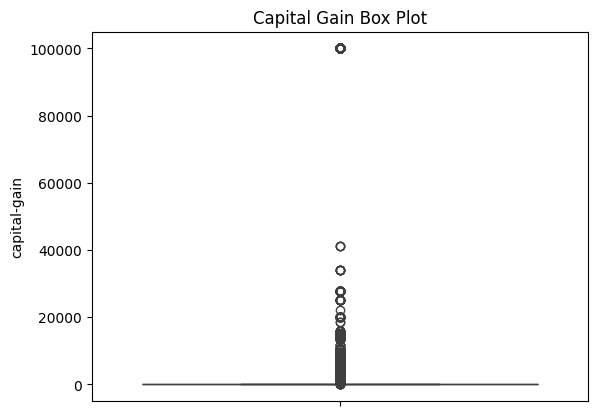

In [19]:
#box plot capital-gain and capital-loss
sns.boxplot(y=df['capital-gain'])
plt.title('Capital Gain Box Plot')
plt.show()

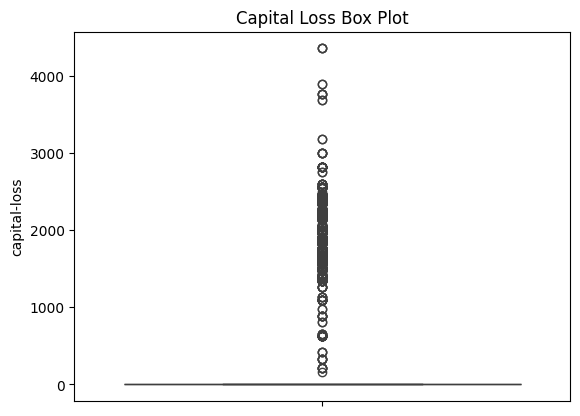

In [20]:
sns.boxplot(y=df['capital-loss'])
plt.title('Capital Loss Box Plot')
plt.show()

In [21]:
df.head(1)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,United-States,<=50K


In [22]:
df['workclass'].value_counts()

,count
workclass,
Private,37325
Self-emp-not-inc,3649
Local-gov,2973
State-gov,1877
Self-emp-inc,1624
Federal-gov,1346
Without-pay,18
Never-worked,9


In [23]:
df['education'].value_counts()

,count
education,
HS-grad,15778
Some-college,10873
Bachelors,8021
Masters,2656
Assoc-voc,2060
11th,1812
Assoc-acdm,1601
10th,1389
7th-8th,955


In [24]:
df['race'].value_counts()

,count
race,
White,41742
Black,4685
Asian-Pac-Islander,1518
Amer-Indian-Eskimo,470
Other,406


In [25]:
df['relationship'].value_counts()

,count
relationship,
Husband,19711
Not-in-family,12570
Own-child,7578
Unmarried,5125
Wife,2331
Other-relative,1506


In [26]:
#Encoding
df = pd.get_dummies(df, columns=['native-country'], prefix='native_to')#onehot
df['sex'] = df['sex'].map({'Male': 0, 'Female': 1})#binary
df = pd.get_dummies(df, columns=['race'], prefix='race')#onehot
df = pd.get_dummies(df, columns=['relationship'], prefix='relationship')#onehot
df = pd.get_dummies(df, columns=['occupation'], prefix='occ')#onehot
df = pd.get_dummies(df, columns=['marital-status'], prefix='marital')#onehot
df = pd.get_dummies(df, columns=['workclass'], prefix='workclass')#onehot

In [27]:
df = df.drop(columns=['education'])

In [28]:
df.head()

,age,fnlwgt,education-num,sex,capital-gain,capital-loss,hours-per-week,income,native_to_Cambodia,native_to_Canada,...,marital_Separated,marital_Widowed,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay
0,39.0,77516.0,13.0,0,2174,0,40.0,<=50K,False,False,...,False,False,False,False,False,False,False,False,True,False
1,50.0,83311.0,13.0,0,0,0,32.5,<=50K,False,False,...,False,False,False,False,False,False,False,True,False,False
2,38.0,215646.0,9.0,0,0,0,40.0,<=50K,False,False,...,False,False,False,False,False,True,False,False,False,False
3,53.0,234721.0,7.0,0,0,0,40.0,<=50K,False,False,...,False,False,False,False,False,True,False,False,False,False
4,28.0,338409.0,13.0,1,0,0,40.0,<=50K,False,False,...,False,False,False,False,False,True,False,False,False,False


In [29]:
df['income'].value_counts()

,count
income,
<=50K,24706
<=50K.,12430
>50K,7839
>50K.,3846


In [30]:
df['income'] = df['income'].str.replace('.', '', regex=False).str.strip()
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})

In [31]:
df.head()

,age,fnlwgt,education-num,sex,capital-gain,capital-loss,hours-per-week,income,native_to_Cambodia,native_to_Canada,...,marital_Separated,marital_Widowed,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay
0,39.0,77516.0,13.0,0,2174,0,40.0,0,False,False,...,False,False,False,False,False,False,False,False,True,False
1,50.0,83311.0,13.0,0,0,0,32.5,0,False,False,...,False,False,False,False,False,False,False,True,False,False
2,38.0,215646.0,9.0,0,0,0,40.0,0,False,False,...,False,False,False,False,False,True,False,False,False,False
3,53.0,234721.0,7.0,0,0,0,40.0,0,False,False,...,False,False,False,False,False,True,False,False,False,False
4,28.0,338409.0,13.0,1,0,0,40.0,0,False,False,...,False,False,False,False,False,True,False,False,False,False


In [32]:
df.shape

(48821, 89)

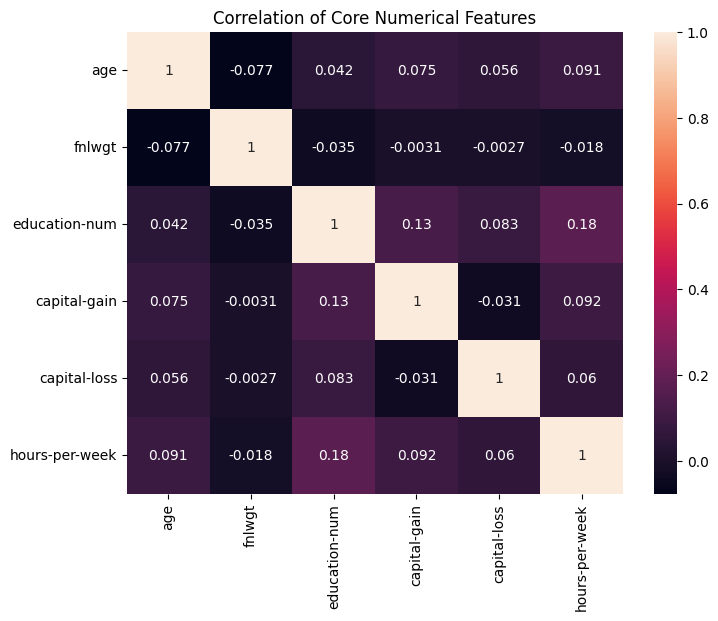

In [33]:
core_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
core_corr = df[core_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(core_corr, annot=True)
plt.title("Correlation of Core Numerical Features")
plt.show()

<Axes: xlabel='age', ylabel='Count'>

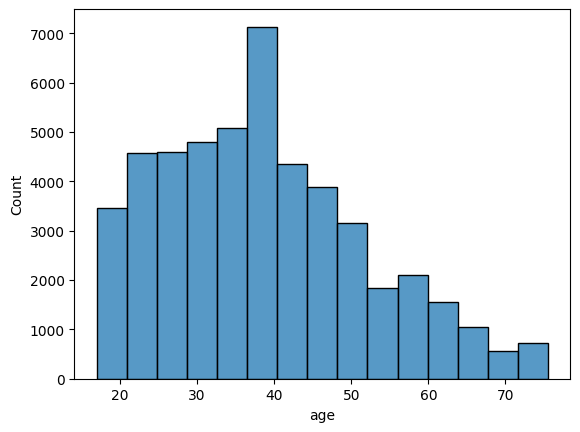

In [34]:
histogram_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
sns.histplot(df['age'],bins=15)


<Axes: xlabel='fnlwgt', ylabel='Count'>

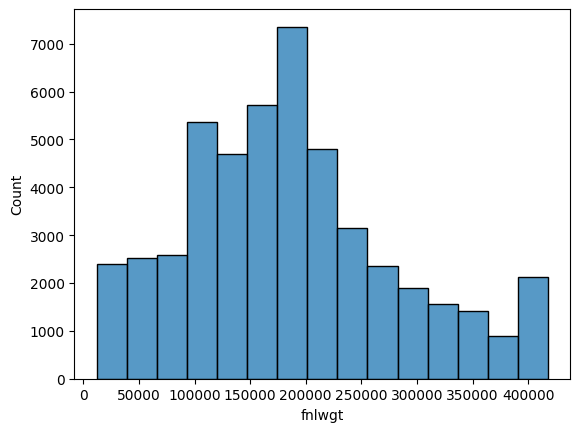

In [35]:
sns.histplot(df['fnlwgt'],bins=15)

In [36]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

income_labels = df['income']
df_features = df.drop(columns=['income'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

In [37]:
#Applying PCA
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Original number of features: {df_features.shape[1]}")
print(f"Reduced number of features (95% variance): {X_pca.shape[1]}")

Original number of features: 88
Reduced number of features (95% variance): 74


In [38]:
#creating new df
pca_columns = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=pca_columns)
df_pca['income'] = income_labels.values

In [39]:
df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC66,PC67,PC68,PC69,PC70,PC71,PC72,PC73,PC74,income
0,-1.031383,1.479476,-1.560896,2.247366,-0.519102,-1.334873,0.051252,-0.142731,-0.768226,-1.681699,...,-0.103639,-0.283744,-0.467094,-0.884603,0.085097,0.074206,-0.117013,-1.222523,1.350251,0
1,2.953237,0.619050,-0.990805,0.862991,-0.127049,-1.222594,0.202500,1.433600,1.121066,0.548739,...,-0.114754,0.646442,0.383373,0.851643,-0.957200,1.031848,0.992043,-1.198314,-1.085029,0
2,-1.134869,0.906549,0.239937,-1.237007,-0.840606,0.035385,-1.813353,-0.346763,-1.044558,-0.853437,...,0.746216,-0.829527,-0.096109,-0.178271,0.213810,0.031477,-0.173511,-0.336283,-0.200214,0
3,0.816067,-1.889715,0.720352,-1.325884,3.634851,0.283194,-0.971481,-0.752450,-0.077232,0.361379,...,0.661662,-0.016722,0.131260,-0.217015,0.610936,-0.570963,-0.315792,-0.425501,0.678358,0
4,-0.669666,-4.136067,-1.328395,-0.198969,0.001357,0.729148,3.901329,-3.445372,2.552043,1.030836,...,-0.739810,0.816722,1.541654,-0.576060,1.319832,-1.773368,1.104214,1.749048,2.060558,0


In [40]:
x = df_pca[['PC1','PC2']]
x.head()

,PC1,PC2
0,-1.031383,1.479476
1,2.953237,0.619050
2,-1.134869,0.906549
3,0.816067,-1.889715
4,-0.669666,-4.136067


<Axes: xlabel='PC1', ylabel='PC2'>

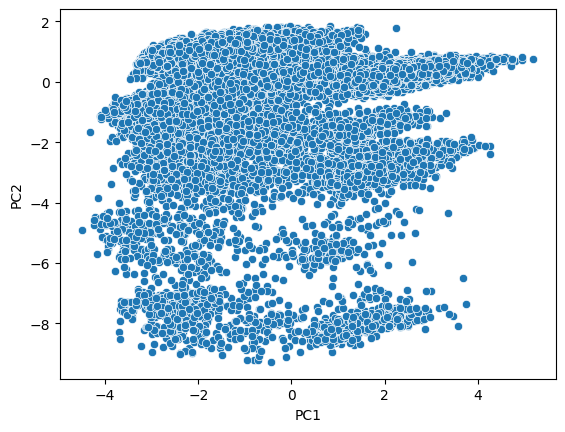

In [41]:
sns.scatterplot(data=df_pca , x='PC1', y='PC2')

In [42]:
x_scaled = scaler.fit_transform(x)

In [43]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss = []

for i in range(2,11):
    km_object = KMeans(n_clusters=i,
                       init='k-means++',
                       max_iter = 300,
                       n_init=10,
                       random_state=0)
    km_object.fit(x_scaled)
    wcss.append(km_object.inertia_)

In [44]:
wcss

[56044.11916647438,
 27385.688487298212,
 18384.969107034485,
 13006.729922011584,
 10407.73348910146,
 8918.920657154913,
 7741.934739116773,
 6862.020328946305,
 6083.495558739476]

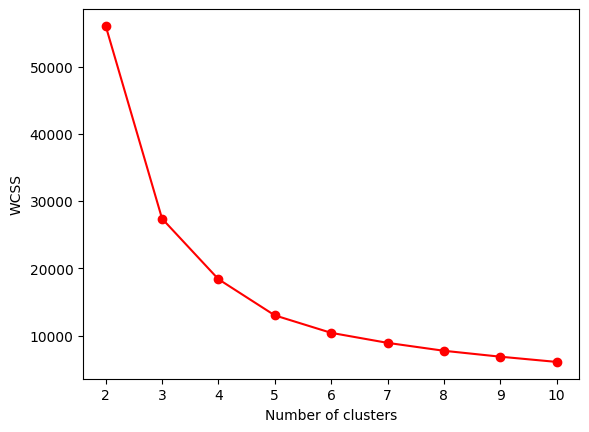

In [45]:
plt.plot(range(2,11),wcss,c='red',marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [46]:
#k=5
km_object = KMeans(n_clusters=5,
                       init='k-means++',
                       max_iter = 300,
                       n_init=10,
                       random_state=0)
km_object.fit(x_scaled)

kmeans_cluster_labels = km_object.labels_
kmeans_cluster_labels

array([0, 1, 0, ..., 1, 3, 1], dtype=int32)

In [47]:
df_pca['kmeans_cluster'] = kmeans_cluster_labels

<Axes: xlabel='PC1', ylabel='PC2'>

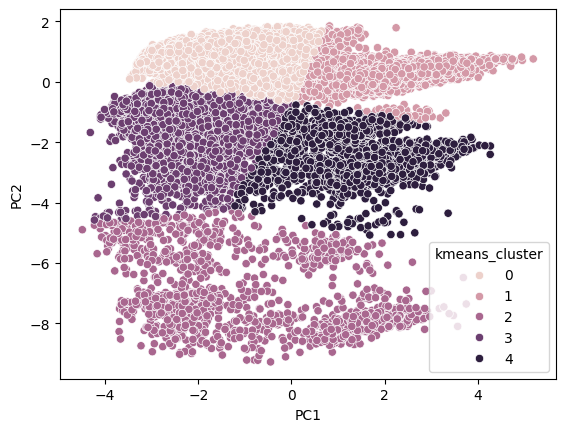

In [48]:
sns.scatterplot(data=df_pca,x='PC1',y='PC2',hue='kmeans_cluster')

In [49]:
#sampling
x_sample = x.sample(n=2000, random_state=42)

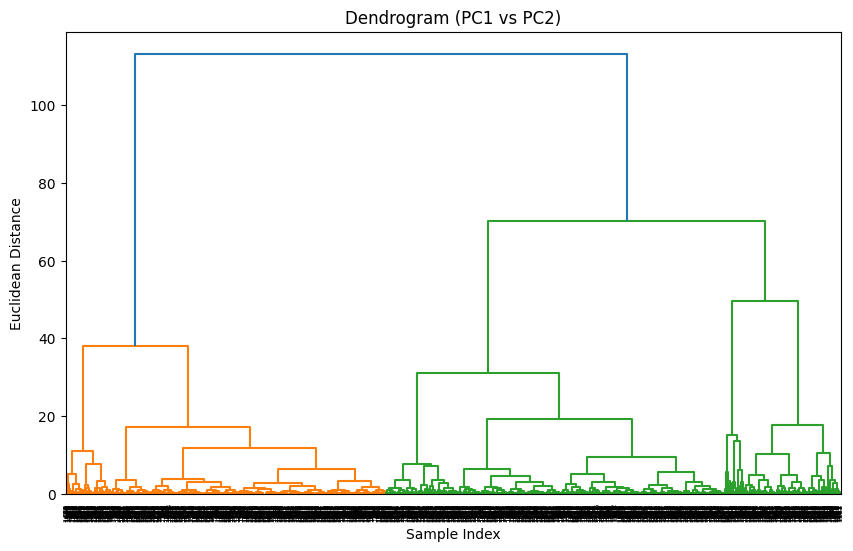

In [51]:
from scipy.cluster.hierarchy import dendrogram, linkage
mergings = linkage(x_sample, method='ward')
plt.figure(figsize=(10, 6))
dendrogram(mergings)
plt.title('Dendrogram (PC1 vs PC2)')
plt.xlabel('Sample Index')
plt.ylabel('Euclidean Distance')
plt.show()

In [53]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

ac_obj = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
ac_clusters = ac_obj.fit_predict(x_sample)
ac_clusters
print("Silhouette Score (Agglomerative):", silhouette_score(x_sample, ac_clusters))

Silhouette Score (Agglomerative): 0.5625058320663723


In [54]:
df_sample = df_pca.loc[x_sample.index].copy()
df_sample['ac_clusters'] = ac_clusters

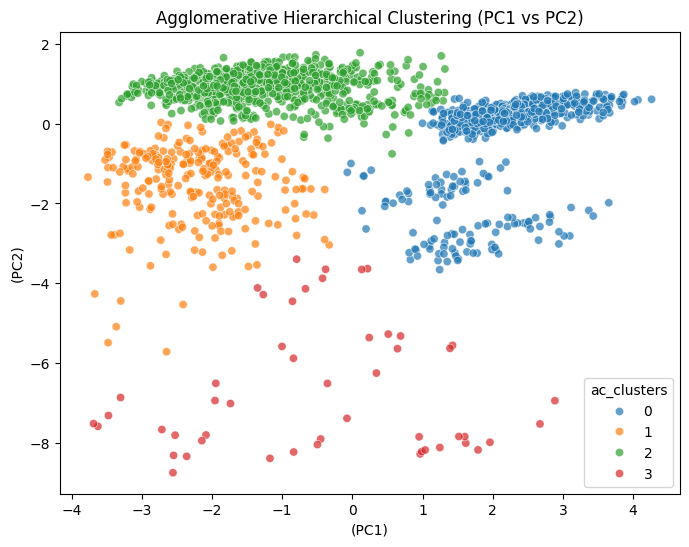

In [56]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_sample,
    x='PC1',
    y='PC2',
    hue='ac_clusters',
    palette='tab10',
    alpha=0.7
)
plt.title('Agglomerative Hierarchical Clustering (PC1 vs PC2)')
plt.xlabel('(PC1)')
plt.ylabel('(PC2)')
plt.show()

In [ ]:
#DBSCAN

In [57]:
from sklearn.cluster import DBSCAN
db = DBSCAN(eps=0.3, min_samples=5)
labels = db.fit_predict(x_scaled)

In [60]:
df_pca['Cluster_db'] = labels
df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC68,PC69,PC70,PC71,PC72,PC73,PC74,income,kmeans_cluster,Cluster_db
0,-1.031383,1.479476,-1.560896,2.247366,-0.519102,-1.334873,0.051252,-0.142731,-0.768226,-1.681699,...,-0.467094,-0.884603,0.085097,0.074206,-0.117013,-1.222523,1.350251,0,0,0
1,2.953237,0.619050,-0.990805,0.862991,-0.127049,-1.222594,0.202500,1.433600,1.121066,0.548739,...,0.383373,0.851643,-0.957200,1.031848,0.992043,-1.198314,-1.085029,0,1,0
2,-1.134869,0.906549,0.239937,-1.237007,-0.840606,0.035385,-1.813353,-0.346763,-1.044558,-0.853437,...,-0.096109,-0.178271,0.213810,0.031477,-0.173511,-0.336283,-0.200214,0,0,0
3,0.816067,-1.889715,0.720352,-1.325884,3.634851,0.283194,-0.971481,-0.752450,-0.077232,0.361379,...,0.131260,-0.217015,0.610936,-0.570963,-0.315792,-0.425501,0.678358,0,4,0
4,-0.669666,-4.136067,-1.328395,-0.198969,0.001357,0.729148,3.901329,-3.445372,2.552043,1.030836,...,1.541654,-0.576060,1.319832,-1.773368,1.104214,1.749048,2.060558,0,4,0


In [61]:
df_pca.value_counts('Cluster_db')

,count
Cluster_db,
0,48818
-1,3


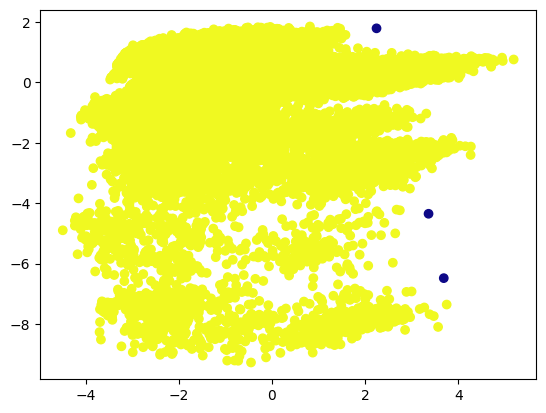

In [62]:
plt.scatter(df_pca['PC1'],
            df_pca['PC2'],
            c=df_pca['Cluster_db'],
            cmap='plasma')